# Anomalous mean-field for non-collinear superconductors

For a Hamiltonian with a Nambu (electron-hole) spinor, `get_mean_field_hamiltonian` also solves the
anomalous (pairing) Wick contraction of the interaction,

$$
H_U^{aMF} = U\sum_{i} \langle c_{i,\uparrow} c_{i,\downarrow} \rangle c^\dagger_{i,\downarrow} c^\dagger_{i,\uparrow} + h.c.
$$

which becomes non-zero for attractive interactions and yields an interaction-induced superconducting
state -- automatically, on top of whatever collinear/non-collinear normal-state order also converges.
An attractive onsite $U$ on a triangular lattice gives conventional spin-singlet $s$-wave pairing; an
attractive first-neighbor $V_1$ combined with a large Zeeman splitting instead favors equal-spin
spin-triplet pairing.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
def kdos_grid(h,es,nk):
    """get_kdos_bands returns 3 flat arrays (k-fraction, energy, dos),
    energies varying fastest -- reshape into a (nk,len(es)) grid for contourf.
    A few (k,e) grid points can land almost exactly on a sharp Bogoliubov
    peak while their neighbors miss it entirely, giving a few pixels a huge
    spectral weight; clipping the colorscale at a high percentile (rather
    than the raw max) keeps the dispersive bands visible instead of being
    washed out by those rare spikes -- the same trick pyqula's own examples
    use (e.g. examples/2d/kdos_and_ribbon, examples/2d/kdos_edge_TSC)."""
    kx,ky,d = h.get_kdos_bands(operator="electron",nk=nk,energies=es)
    return np.unique(kx), es, d.reshape(nk,len(es)).T

# singlet s-wave superconductivity from attractive onsite U
g = geometry.triangular_lattice()
h = g.get_hamiltonian()
h.setup_nambu_spinor()
h = h.get_mean_field_hamiltonian(U=-1.0,filling=0.15,mf="swave")
es_s = np.linspace(-1.0,1.0,120)
x_s,y_s,d_s = kdos_grid(h,es_s,250)

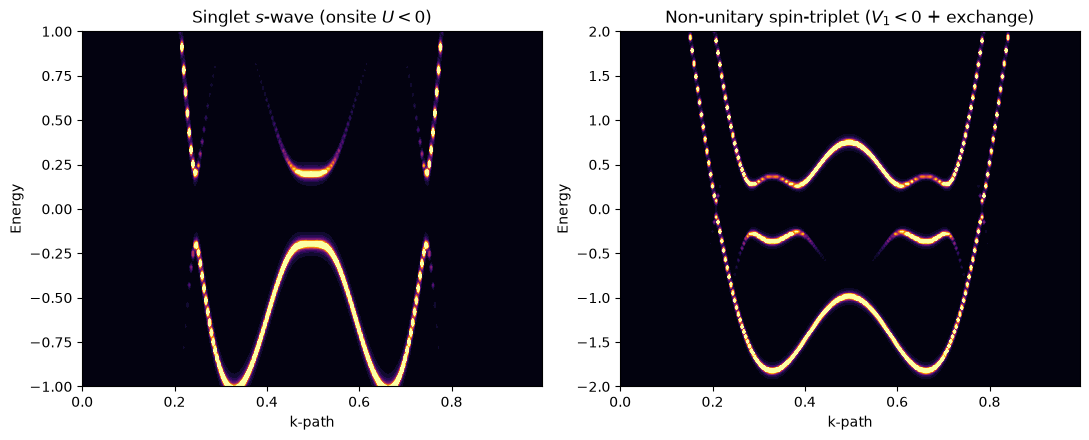

In [2]:
# non-unitary spin-triplet superconductivity from an exchange field + attractive V1
g2 = geometry.triangular_lattice()
h2 = g2.get_hamiltonian()
h2.add_exchange([0.,0.,1.])
h2.setup_nambu_spinor()
h2 = h2.get_mean_field_hamiltonian(V1=-1.0,filling=0.3,mf="random")
es_t = np.linspace(-2.0,2.0,150)
x_t,y_t,d_t = kdos_grid(h2,es_t,250)

fig,axs = plt.subplots(1,2,figsize=(11,4.5))
axs[0].contourf(x_s,y_s,d_s,levels=100,cmap="inferno",vmax=np.percentile(d_s,99))
axs[0].set_title("Singlet $s$-wave (onsite $U<0$)")
axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Energy")
axs[1].contourf(x_t,y_t,d_t,levels=100,cmap="inferno",vmax=np.percentile(d_t,99))
axs[1].set_title("Non-unitary spin-triplet ($V_1<0$ + exchange)")
axs[1].set_xlabel("k-path") ; axs[1].set_ylabel("Energy")
plt.tight_layout()
plt.show()